--- Model Performance ---
Accuracy Score: 89.25%

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.96       105
           1       0.89      0.87      0.88        91
           2       0.78      0.87      0.82        92
           3       0.94      0.87      0.90       112

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.90      0.89      0.89       400



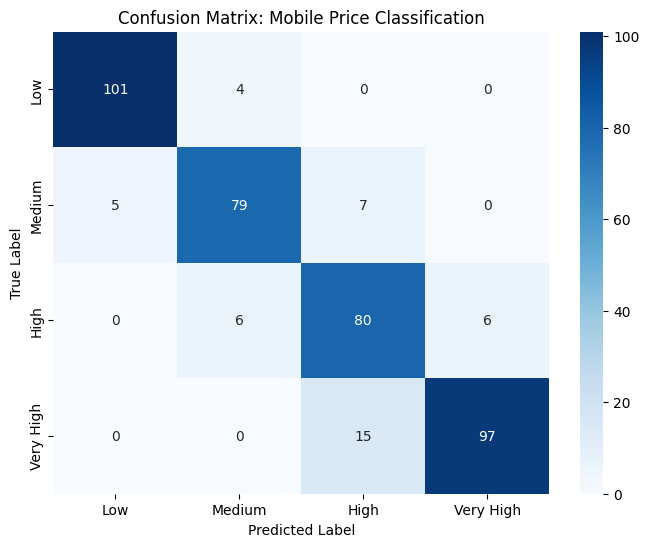

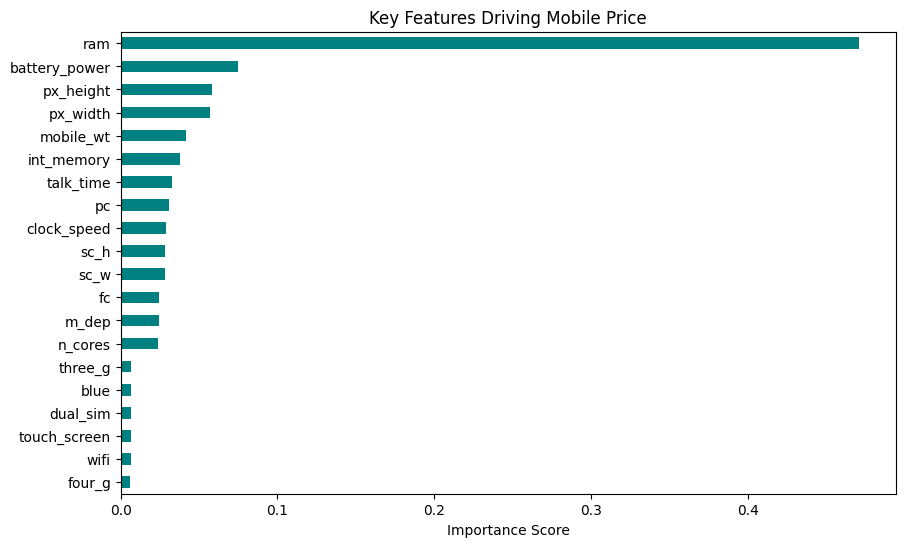


--- Prediction Result ---
The predicted Price Range for the sample mobile is: High Cost


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load the dataset
# Ensure the file 'data_mobile_price_range.csv' is in the same directory
df = pd.read_csv('data_mobile_price_range.csv')

# 2. Separate Features (X) and Target (y)
X = df.drop('price_range', axis=1)
y = df['price_range']

# 3. Split the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling
# Scaling helps the model converge faster and keeps feature weights balanced
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Initialize and Train the Random Forest Classifier
# n_estimators=100 creates 100 decision trees for better accuracy
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 6. Make Predictions on the Test Set
y_pred = rf_model.predict(X_test_scaled)

# 7. Model Evaluation
print("--- Model Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 8. Visualization: Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High', 'Very High'],
            yticklabels=['Low', 'Medium', 'High', 'Very High'])
plt.title('Confusion Matrix: Mobile Price Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 9. Visualization: Feature Importance
# This shows which specs (like RAM or Battery) matter most for the price
plt.figure(figsize=(10, 6))
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Key Features Driving Mobile Price')
plt.xlabel('Importance Score')
plt.show()

# 10. PREDICTION: Predict for a specific new mobile
# Example Input: [battery_power, blue, clock_speed, dual_sim, fc, four_g, int_memory,
#                 m_dep, mobile_wt, n_cores, pc, px_height, px_width, ram, sc_h,
#                 sc_w, talk_time, three_g, touch_screen, wifi]
sample_mobile = [[1200, 1, 2.0, 0, 5, 1, 32, 0.5, 145, 4, 12, 700, 1100, 2500, 12, 7, 12, 1, 0, 1]]

# Scale the sample input just like the training data
sample_scaled = scaler.transform(sample_mobile)

# Get prediction
predicted_class = rf_model.predict(sample_scaled)[0]

price_map = {0: "Low Cost", 1: "Medium Cost", 2: "High Cost", 3: "Very High Cost"}
print(f"\n--- Prediction Result ---")
print(f"The predicted Price Range for the sample mobile is: {price_map[predicted_class]}")